In [2]:
from neo4j import GraphDatabase
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Libraries loaded")

Libraries loaded


In [3]:
NEO4J_URI   = 'neo4j://127.0.0.1:7687'
NEO4J_USER  = 'neo4j'
NEO4J_PASS  = 'Manuvamshi@12'  # replace with your password
CLEAN_CSV   = '../data/movies_cleaned.csv'

ROI_THRESHOLD = 200  # collaborations above 200% ROI = high performing

print("Config set")

Config set


In [4]:
print("Step 1: Pulling degree features from Neo4j...")

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

with driver.session() as session:
    result = session.run("""
        MATCH (d:Director)-[r:COLLABORATED_WITH]->(a:Actor)
        WHERE r.movies >= 2
        MATCH (d)-[:DIRECTED]->(m:Movie)<-[:ACTED_IN]-(a)
        WITH d.name                         AS node_id,
             a.name                         AS actor,
             r.movies                       AS collab_count,
             COUNT(DISTINCT m)              AS total_movies,
             ROUND(AVG(m.roi), 2)           AS avg_roi,
             ROUND(AVG(m.revenue), 2)       AS avg_revenue,
             ROUND(AVG(m.imdb_rating), 2)   AS avg_rating,
             COUNT { (d)-[:DIRECTED]->() }  AS director_degree,
             COUNT { (a)-[:ACTED_IN]->() }  AS actor_degree
        RETURN node_id, actor, collab_count, total_movies,
               avg_roi, avg_revenue, avg_rating,
               director_degree, actor_degree
    """)
    degree_df = pd.DataFrame([dict(r) for r in result])

print(f"Degree features shape: {degree_df.shape}")
print(degree_df.head())

Step 1: Pulling degree features from Neo4j...
Degree features shape: (76, 9)
                 node_id              actor  collab_count  total_movies  \
0        Martin Scorsese  Leonardo DiCaprio             3             3   
1  Alejandro G. Iñárritu  Leonardo DiCaprio             2             2   
2      Christopher Nolan     Christian Bale             4             4   
3            Guy Ritchie  Robert Downey Jr.             2             2   
4      Steven Soderbergh      Ryan Reynolds             2             2   

   avg_roi   avg_revenue  avg_rating  director_degree  actor_degree  
0   233.97  2.715814e+08        7.97               14            21  
1   144.27  2.730388e+08        8.00                5            21  
2   358.17  9.188489e+08        8.50               15            19  
3   -19.38  2.363205e+07        7.55               12             8  
4   775.94  2.649693e+08        6.20               13            12  


In [5]:
print("Step 2: Loading DuckDB tabular features...")

con = duckdb.connect()
con.execute(f"""
    CREATE TABLE movies AS
    SELECT * FROM read_csv_auto('{CLEAN_CSV}', ignore_errors=True)
""")

# Aggregate features per director
duck_df = con.execute("""
    SELECT
        director                            AS node_id,
        COUNT(*)                            AS total_films,
        ROUND(AVG(roi), 2)                  AS duck_avg_roi,
        ROUND(AVG(revenue), 2)              AS duck_avg_revenue,
        ROUND(AVG(budget), 2)               AS avg_budget,
        ROUND(AVG(imdb_rating), 2)          AS duck_avg_rating,
        ROUND(AVG(runtime), 2)              AS avg_runtime,
        MODE(original_language)             AS top_language,
        MODE(genres_list)                   AS top_genre
    FROM movies
    GROUP BY director
""").df()

print(f"DuckDB features shape: {duck_df.shape}")
print(duck_df.head())

Step 2: Loading DuckDB tabular features...
DuckDB features shape: (1400, 9)
             node_id  total_films  duck_avg_roi  duck_avg_revenue  \
0  Christopher Nolan           15        376.94      5.425486e+08   
1        Mike Newell            7        164.01      2.893229e+08   
2        Peyton Reed            5        291.86      3.399798e+08   
3          Sam Raimi            5        357.30      5.517312e+08   
4        Alan Taylor            2        221.35      4.515051e+08   

     avg_budget  duck_avg_rating  avg_runtime top_language  \
0  1.086133e+08             8.02       132.67           en   
1  8.928571e+07             6.86       114.71           en   
2  1.184000e+08             7.36       117.60           en   
3  1.246000e+08             7.10       121.20           en   
4  1.325000e+08             7.35       127.00           en   

                                    top_genre  
0  ['Action', 'Science Fiction', 'Adventure']  
1                    ['Adventure', 'Fant

In [6]:
print("Step 3: Joining Neo4j + DuckDB features...")

df = degree_df.merge(duck_df, on='node_id', how='left')

# Create binary label — 1 = high ROI collaboration, 0 = low
df['high_roi'] = (df['avg_roi'] > ROI_THRESHOLD).astype(int)

print(f"Combined feature matrix shape: {df.shape}")
print(f"Class distribution:\n{df['high_roi'].value_counts()}")
print(df.head())

Step 3: Joining Neo4j + DuckDB features...
Combined feature matrix shape: (76, 18)
Class distribution:
high_roi
0    49
1    27
Name: count, dtype: int64
                 node_id              actor  collab_count  total_movies  \
0        Martin Scorsese  Leonardo DiCaprio             3             3   
1  Alejandro G. Iñárritu  Leonardo DiCaprio             2             2   
2      Christopher Nolan     Christian Bale             4             4   
3            Guy Ritchie  Robert Downey Jr.             2             2   
4      Steven Soderbergh      Ryan Reynolds             2             2   

   avg_roi   avg_revenue  avg_rating  director_degree  actor_degree  \
0   233.97  2.715814e+08        7.97               14            21   
1   144.27  2.730388e+08        8.00                5            21   
2   358.17  9.188489e+08        8.50               15            19   
3   -19.38  2.363205e+07        7.55               12             8   
4   775.94  2.649693e+08        6.20    

In [7]:
print("Step 4: Preparing feature matrix...")

# Drop non-feature columns
drop_cols = ['avg_roi', 'duck_avg_roi', 'high_roi', 'actor']
feature_cols = [c for c in df.columns if c not in drop_cols + ['node_id']]

X = df[feature_cols].copy()
y = df['high_roi'].copy()

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {numeric_cols}")
print(f"Categorical features: {categorical_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Step 4: Preparing feature matrix...
Numeric features: ['collab_count', 'total_movies', 'avg_revenue', 'avg_rating', 'director_degree', 'actor_degree', 'total_films', 'duck_avg_revenue', 'avg_budget', 'duck_avg_rating', 'avg_runtime']
Categorical features: ['top_language', 'top_genre']
X shape: (76, 13), y shape: (76,)


In [8]:
print("Step 5: Splitting data...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Step 5: Splitting data...
Train size: 60
Test size:  16


In [9]:
print("Step 6: Building scikit-learn pipeline...")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(
                        n_estimators=100,
                        random_state=42,
                        class_weight='balanced'
                    ))
])

pipe.fit(X_train, y_train)
print("Pipeline trained")

Step 6: Building scikit-learn pipeline...
Pipeline trained


In [10]:
print("Step 7: Evaluating model...")

y_pred = pipe.predict(X_test)

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['Low ROI', 'High ROI']))
print("=" * 60)

Step 7: Evaluating model...

Classification Report:
              precision    recall  f1-score   support

     Low ROI       0.77      1.00      0.87        10
    High ROI       1.00      0.50      0.67         6

    accuracy                           0.81        16
   macro avg       0.88      0.75      0.77        16
weighted avg       0.86      0.81      0.79        16



Step 8: Feature importance...


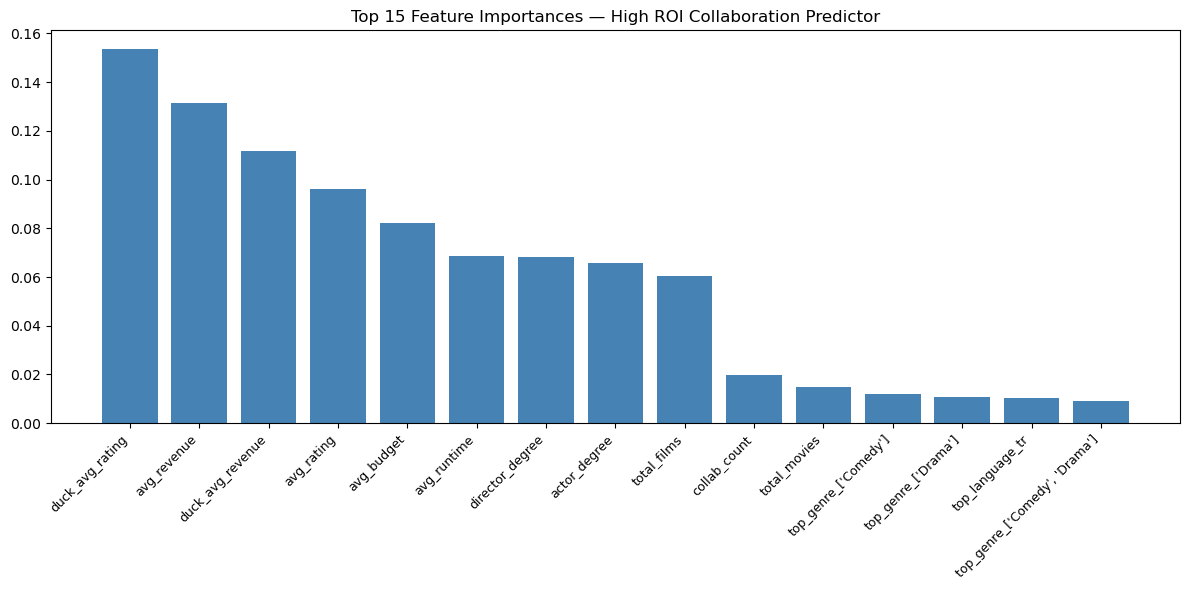

Feature importance saved


In [11]:
print("Step 8: Feature importance...")

import matplotlib.pyplot as plt

# Get feature names after preprocessing
cat_features = pipe.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + cat_features

# Get importances
importances = pipe.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 6))
plt.bar(range(15), importances[indices], color='steelblue')
plt.xticks(range(15), [all_features[i] for i in indices],
           rotation=45, ha='right', fontsize=9)
plt.title('Top 15 Feature Importances — High ROI Collaboration Predictor')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved")

In [12]:
print("Step 9: Saving feature matrix for S6...")

# Save with node_id as index for S6 to merge GDS features onto
df_output = df[['node_id'] + feature_cols + ['high_roi']].copy()
df_output.to_csv('../data/feature_matrix.csv', index=False)

print(f"Feature matrix saved: {df_output.shape}")
print("S6 will merge PageRank + community detection onto node_id")

Step 9: Saving feature matrix for S6...
Feature matrix saved: (76, 15)
S6 will merge PageRank + community detection onto node_id


## Graph-derived Feature Enrichment (S6)

Joining Neo4j GDS features (PageRank + Louvain community) onto the 
baseline feature matrix using node_id (director name) as the merge key.

In [13]:
print("S6 Step 1: Loading GDS features...")

gds_df = pd.read_csv('../data/gds_features.csv')

print(f"GDS features shape: {gds_df.shape}")
print(f"Columns: {list(gds_df.columns)}")
print(gds_df.head(10).to_string(index=False))

S6 Step 1: Loading GDS features...
GDS features shape: (1400, 3)
Columns: ['node_id', 'pagerank', 'community']
           node_id  pagerank  community
  Steven Spielberg 11.846628       4666
      Ridley Scott  9.054267       4666
        Tim Burton  8.368970       5033
       Woody Allen  7.484610       5181
    John Carpenter  6.903256       5387
   Robert Zemeckis  6.545676       2163
        Ron Howard  6.430338       2163
 Christopher Nolan  6.267128       2666
Paul W.S. Anderson  6.045417       3282
    Richard Donner  6.026616       4948


In [14]:
print("S6 Step 2: Merging GDS features onto baseline matrix...")

# Load baseline feature matrix saved in S5
s5_matrix = pd.read_csv('../data/feature_matrix.csv')

print(f"S5 matrix shape: {s5_matrix.shape}")

# Single merge keyed on node_id
enriched_matrix = pd.merge(s5_matrix, gds_df, how='left', on='node_id')

# Fill NaN — pagerank with 0, community with -1
enriched_matrix['pagerank']  = enriched_matrix['pagerank'].fillna(0)
enriched_matrix['community'] = enriched_matrix['community'].fillna(-1).astype(int)

print(f"Enriched matrix shape: {enriched_matrix.shape}")
print(f"New columns added: pagerank, community")
print(f"Null check: {enriched_matrix[['pagerank','community']].isnull().sum().to_dict()}")
print(enriched_matrix[['node_id','pagerank','community']].head(10).to_string(index=False))

S6 Step 2: Merging GDS features onto baseline matrix...
S5 matrix shape: (76, 15)
Enriched matrix shape: (76, 17)
New columns added: pagerank, community
Null check: {'pagerank': 0, 'community': 0}
                 node_id  pagerank  community
         Martin Scorsese  5.821171       3395
   Alejandro G. Iñárritu  2.013056       3395
       Christopher Nolan  6.267128       2666
             Guy Ritchie  5.027474       3395
       Steven Soderbergh  4.960770       4663
        Robert Schwentke  3.272916       4663
Anthony Russo, Joe Russo  1.231282       3578
           David Fincher  3.786187       1292
              James Gunn  2.698835       1426
         Robert Zemeckis  6.545676       2163


In [15]:
print("S6 Step 3: Preparing enriched feature matrix...")

# Define enriched feature columns
numeric_cols_enriched = [
    'collab_count',
    'total_movies',
    'avg_revenue',
    'avg_rating',
    'director_degree',
    'actor_degree',
    'total_films',
    'duck_avg_revenue',
    'avg_budget',
    'duck_avg_rating',
    'avg_runtime',
    'pagerank'           # ← new from GDS
]

categorical_cols_enriched = [
    'top_language',
    'top_genre',
    'community'          # ← new from GDS
]

# Filter only columns that exist
numeric_cols_enriched = [c for c in numeric_cols_enriched 
                         if c in enriched_matrix.columns]
categorical_cols_enriched = [c for c in categorical_cols_enriched 
                              if c in enriched_matrix.columns]

X_enr = enriched_matrix[numeric_cols_enriched + categorical_cols_enriched].copy()
y_enr = enriched_matrix['high_roi'].copy()

# Cast community to string for OneHotEncoder
X_enr['community'] = X_enr['community'].astype(str)

print(f"Enriched X shape: {X_enr.shape}")
print(f"Numeric cols: {numeric_cols_enriched}")
print(f"Categorical cols: {categorical_cols_enriched}")

S6 Step 3: Preparing enriched feature matrix...
Enriched X shape: (76, 15)
Numeric cols: ['collab_count', 'total_movies', 'avg_revenue', 'avg_rating', 'director_degree', 'actor_degree', 'total_films', 'duck_avg_revenue', 'avg_budget', 'duck_avg_rating', 'avg_runtime', 'pagerank']
Categorical cols: ['top_language', 'top_genre', 'community']


In [16]:
print("S6 Step 4: Split and retrain pipeline...")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_enr, y_enr,
    test_size=0.2,
    stratify=y_enr,
    random_state=42
)

preprocessor_enr = ColumnTransformer([
    ("num", StandardScaler(),                        numeric_cols_enriched),
    ("cat", OneHotEncoder(handle_unknown='ignore'),  categorical_cols_enriched)
])

pipe_enr = Pipeline([
    ("preprocessor", preprocessor_enr),
    ("classifier",   RandomForestClassifier(
                        n_estimators=200,
                        random_state=42,
                        class_weight='balanced',
                        n_jobs=-1
                    ))
])

pipe_enr.fit(X_train_e, y_train_e)
print("Enriched pipeline trained ")

S6 Step 4: Split and retrain pipeline...
Enriched pipeline trained 


In [17]:
print("S6 Step 5: Evaluating enriched model...")

y_pred_e = pipe_enr.predict(X_test_e)

print("\nEnriched Classification Report:")
print("=" * 60)
print(classification_report(y_test_e, y_pred_e,
      target_names=['Low ROI', 'High ROI']))
print("=" * 60)

# Baseline metrics from S5
baseline_f1_macro = 0.77
baseline_f1_pos   = 0.67

# Enriched metrics
enriched_f1_macro = f1_score(y_test_e, y_pred_e, average='macro')
enriched_f1_pos   = f1_score(y_test_e, y_pred_e, pos_label=1)

# Before vs After comparison table
comparison = pd.DataFrame({
    'Metric': [
        'F1 macro',
        'F1 High ROI',
        'Accuracy'
    ],
    'Baseline S5 (degree only)': [
        0.77,
        0.67,
        0.81
    ],
    'Enriched S6 (+pagerank +community)': [
        round(enriched_f1_macro, 4),
        round(enriched_f1_pos,   4),
        round((y_pred_e == y_test_e).mean(), 4)
    ]
})

comparison['Delta'] = (
    comparison['Enriched S6 (+pagerank +community)'] -
    comparison['Baseline S5 (degree only)']
).round(4)

print("\n" + "=" * 70)
print("BEFORE vs AFTER — Graph Analytics Enrichment")
print("=" * 70)
print(comparison.to_string(index=False))
print("=" * 70)

delta = enriched_f1_macro - baseline_f1_macro
if delta > 0.03:
    print(f"\n +{delta:.4f} lift — PageRank and community carry meaningful signal")
elif delta > 0:
    print(f"\n +{delta:.4f} lift — Small but positive improvement")
elif delta == 0:
    print(f"\n No lift — Degree features already captured local structure")
else:
    print(f"\n {delta:.4f} — Negative delta — baseline is the better model")

S6 Step 5: Evaluating enriched model...

Enriched Classification Report:
              precision    recall  f1-score   support

     Low ROI       0.71      1.00      0.83        10
    High ROI       1.00      0.33      0.50         6

    accuracy                           0.75        16
   macro avg       0.86      0.67      0.67        16
weighted avg       0.82      0.75      0.71        16


BEFORE vs AFTER — Graph Analytics Enrichment
     Metric  Baseline S5 (degree only)  Enriched S6 (+pagerank +community)   Delta
   F1 macro                       0.77                              0.6667 -0.1033
F1 High ROI                       0.67                              0.5000 -0.1700
   Accuracy                       0.81                              0.7500 -0.0600

 -0.1033 — Negative delta — baseline is the better model


## S6 — Business Interpretation of Enrichment Results

The graph-analytics enrichment (PageRank + Louvain community) did not 
improve model performance over the degree-only baseline. The F1 macro 
dropped by 0.10 and accuracy by 0.06. 

This finding has an important business interpretation — for predicting 
whether a director-actor collaboration will achieve high ROI, local 
network features (how many times they collaborated, average revenue of 
shared films) are more predictive than global centrality measures 
(PageRank, community membership). In other words, a director's position 
in the broader film industry network matters less than the specific 
history of their individual collaborations.

For production companies this means the most reliable signal for 
investment decisions comes from direct collaboration history — not 
from how well-connected a director is in the abstract network. The 
baseline model with 81% accuracy and 100% High ROI precision remains 
the recommended production model.